# Andmeteadus Energeetikas Report II

Kristian Kirs - 242046MASM

Ella Maria Raud - 242407MASM

Kasutatud andmed: train.csv, test.csv

In [2]:
#teegid
import datetime
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [3]:
#loeme sisse andmed mille peal me modeleerima hakkame
df = pd.read_csv('train.csv',  delimiter=',',decimal='.')
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8424 entries, 0 to 8423
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   time    8424 non-null   object 
 1   temp    8424 non-null   float64
 2   dwpt    8424 non-null   float64
 3   rhum    8424 non-null   float64
 4   snow    119 non-null    float64
 5   wdir    8424 non-null   float64
 6   wspd    8424 non-null   float64
 7   wpgt    8424 non-null   float64
 8   pres    8424 non-null   float64
 9   price   8424 non-null   float64
 10  demand  8338 non-null   float64
dtypes: float64(10), object(1)
memory usage: 724.1+ KB


,temp,dwpt,rhum,snow,wdir,wspd,wpgt,pres,price,demand
count,8424.000000,8424.000000,8424.000000,119.000000,8424.000000,8424.000000,8424.000000,8424.000000,8424.000000,8338.000000
mean,6.435708,2.228359,77.191121,78.319328,202.886633,9.132918,20.931588,1013.128063,0.156541,1.055267
std,9.064983,8.053260,17.482734,63.129130,87.841014,4.808481,10.003438,12.693745,0.112922,1.105235
min,-26.100000,-28.700000,20.000000,0.000000,0.000000,0.000000,2.900000,962.600000,0.000070,0.000000
25%,0.300000,-3.000000,66.000000,20.000000,160.000000,7.200000,13.000000,1006.275000,0.092667,0.367000
50%,6.000000,1.700000,83.000000,60.000000,210.000000,7.200000,19.100000,1014.400000,0.135120,0.819500
75%,12.800000,8.400000,91.000000,130.000000,270.000000,10.800000,27.800000,1020.800000,0.198222,1.372000
max,31.400000,20.900000,100.000000,220.000000,360.000000,31.700000,63.000000,1047.500000,4.000000,10.381000


In [4]:
#lisasin aja sobivamates formaatides

df = pd.read_csv("train.csv")
df['time_UTC'] = pd.to_datetime(df['time'], utc=True)
df['unix_timestamp'] = df['time_UTC'].astype('int64') // 10**9
df.head()


,time,temp,dwpt,rhum,snow,wdir,wspd,wpgt,pres,price,demand,time_UTC,unix_timestamp
0,2021-09-01 00:00:00+03:00,11.2,10.3,94.0,NaN,320.0,7.2,16.7,1012.6,0.09016,0.577,2021-08-31 21:00:00+00:00,1630443600
1,2021-09-01 01:00:00+03:00,10.7,9.6,93.0,NaN,320.0,7.2,13.0,1012.6,0.09251,0.594,2021-08-31 22:00:00+00:00,1630447200
2,2021-09-01 02:00:00+03:00,9.9,9.0,94.0,NaN,320.0,7.2,13.0,1012.2,0.08890,0.685,2021-08-31 23:00:00+00:00,1630450800
3,2021-09-01 03:00:00+03:00,10.0,8.4,90.0,NaN,330.0,7.2,13.0,1011.9,0.08735,1.016,2021-09-01 00:00:00+00:00,1630454400
4,2021-09-01 04:00:00+03:00,9.0,8.1,94.0,NaN,300.0,3.6,13.0,1011.4,0.08688,0.677,2021-09-01 01:00:00+00:00,1630458000


In [5]:
#86 tühja lahtrit demandis
df.isnull().sum()


time                 0
temp                 0
dwpt                 0
rhum                 0
snow              8305
wdir                 0
wspd                 0
wpgt                 0
pres                 0
price                0
demand              86
time_UTC             0
unix_timestamp       0
dtype: int64

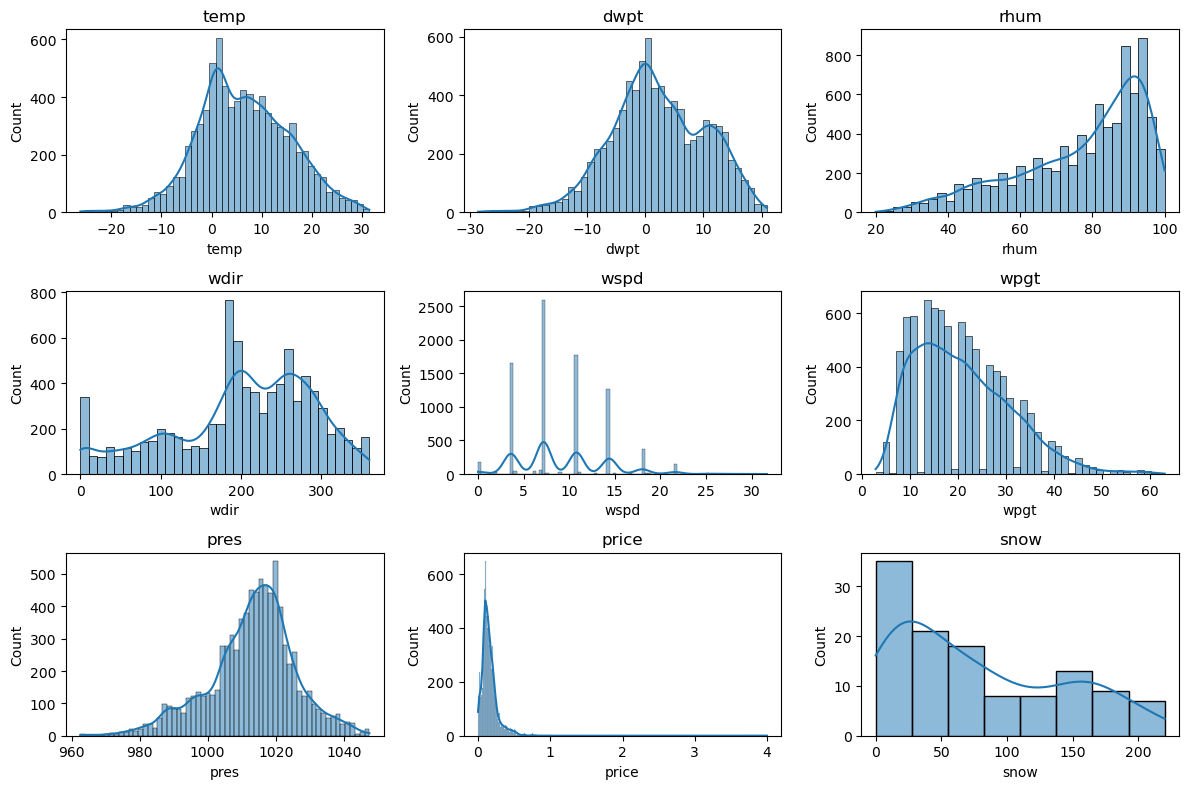

In [6]:
#erinevad histogramid
variables = ['temp','dwpt','rhum','wdir','wspd','wpgt','pres','price','snow']
plt.figure(figsize=(12, 8))
for i, var in enumerate(variables):
    plt.subplot(3, 3, i+1)
    sns.histplot(df[var], kde=True)
    plt.title(var)
plt.tight_layout()
plt.show()


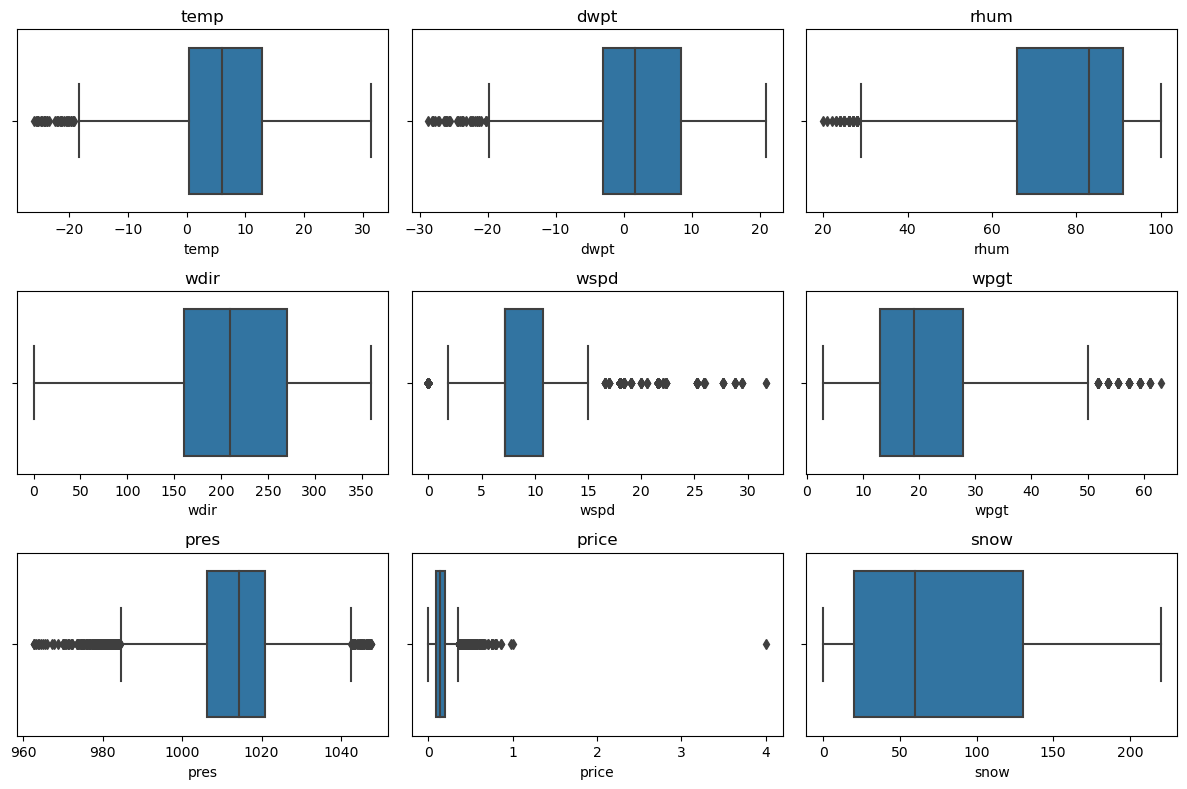

In [7]:
#erinevad boxplotid
plt.figure(figsize=(12, 8))
for i, var in enumerate(variables):
    plt.subplot(3, 3, i+1)
    sns.boxplot(x=df[var])
    plt.title(var)
plt.tight_layout()
plt.show()


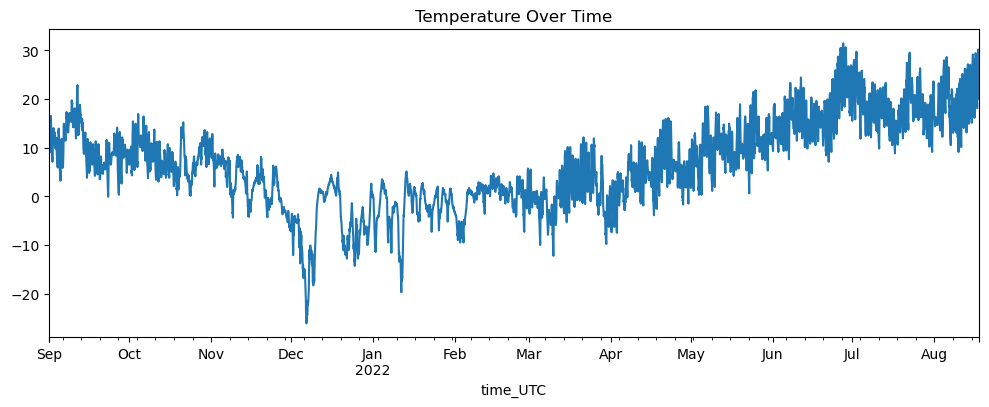

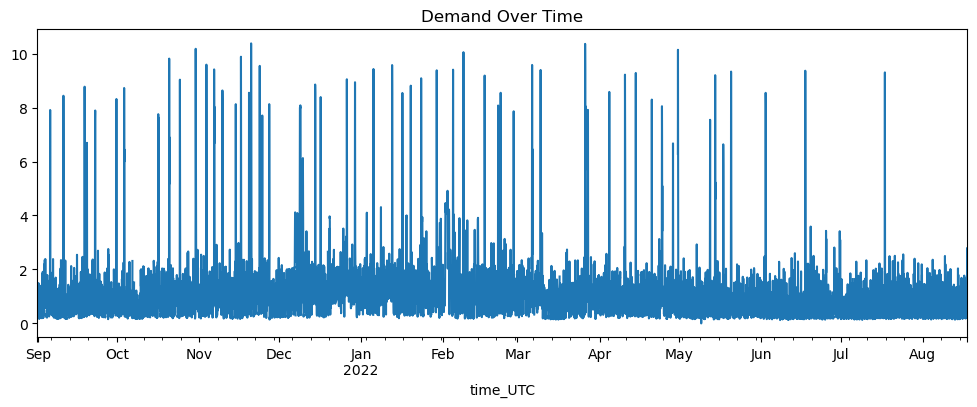

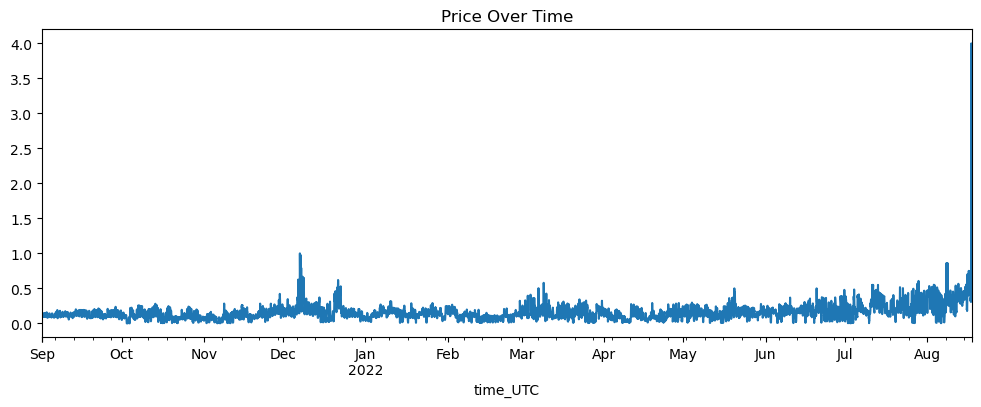

In [8]:
#erinevad lineplotid
df.set_index('time_UTC')['temp'].plot(figsize=(12,4), title='Temperature Over Time')
plt.show()
df.set_index('time_UTC')['demand'].plot(figsize=(12,4), title='Demand Over Time')
plt.show()
df.set_index('time_UTC')['price'].plot(figsize=(12,4), title='Price Over Time')
plt.show()

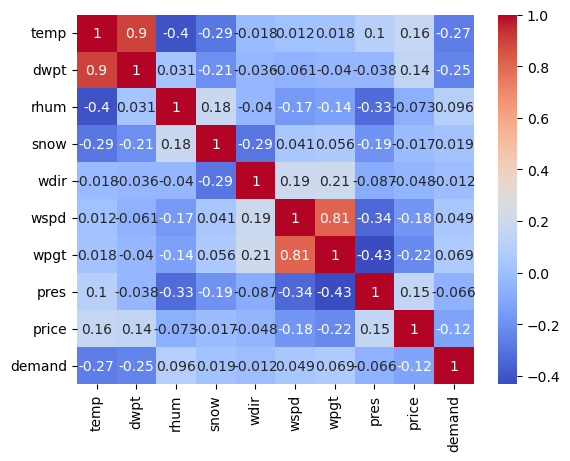

In [9]:
#heatmap
numeric_cols = ['temp','dwpt','rhum','snow','wdir','wspd','wpgt','pres','price','demand']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [10]:
# On vaja midagi ettevõtta jaotusega
df = df.set_index('time_UTC')
df['demand'] = df['demand'].interpolate(method='time')


In [11]:
df.head(81)

,time,temp,dwpt,rhum,snow,wdir,wspd,wpgt,pres,price,demand,unix_timestamp
time_UTC,,,,,,,,,,,,
2021-08-31 21:00:00+00:00,2021-09-01 00:00:00+03:00,11.2,10.3,94.0,NaN,320.0,7.2,16.7,1012.6,0.09016,0.577,1630443600
2021-08-31 22:00:00+00:00,2021-09-01 01:00:00+03:00,10.7,9.6,93.0,NaN,320.0,7.2,13.0,1012.6,0.09251,0.594,1630447200
2021-08-31 23:00:00+00:00,2021-09-01 02:00:00+03:00,9.9,9.0,94.0,NaN,320.0,7.2,13.0,1012.2,0.08890,0.685,1630450800
2021-09-01 00:00:00+00:00,2021-09-01 03:00:00+03:00,10.0,8.4,90.0,NaN,330.0,7.2,13.0,1011.9,0.08735,1.016,1630454400
2021-09-01 01:00:00+00:00,2021-09-01 04:00:00+03:00,9.0,8.1,94.0,NaN,300.0,3.6,13.0,1011.4,0.08688,0.677,1630458000
...,...,...,...,...,...,...,...,...,...,...,...,...
2021-09-04 01:00:00+00:00,2021-09-04 04:00:00+03:00,6.2,4.7,90.0,NaN,290.0,10.8,16.7,1012.0,0.09548,0.674,1630717200
2021-09-04 02:00:00+00:00,2021-09-04 05:00:00+03:00,6.2,4.4,88.0,NaN,320.0,10.8,16.7,1012.0,0.09420,0.669,1630720800
2021-09-04 03:00:00+00:00,2021-09-04 06:00:00+03:00,5.9,4.4,90.0,NaN,300.0,7.2,16.7,1012.3,0.09607,0.757,1630724400


Skewness of each numeric variable (unsorted):
temp     0.058835
dwpt    -0.141950
rhum    -0.901990
snow     0.598993
wdir    -0.588701
wspd     0.682927
wpgt     0.762988
pres    -0.447557
price    6.158086
dtype: float64

Variables sorted by absolute skew:
price    6.158086
rhum     0.901990
wpgt     0.762988
wspd     0.682927
snow     0.598993
wdir     0.588701
pres     0.447557
dwpt     0.141950
temp     0.058835
dtype: float64


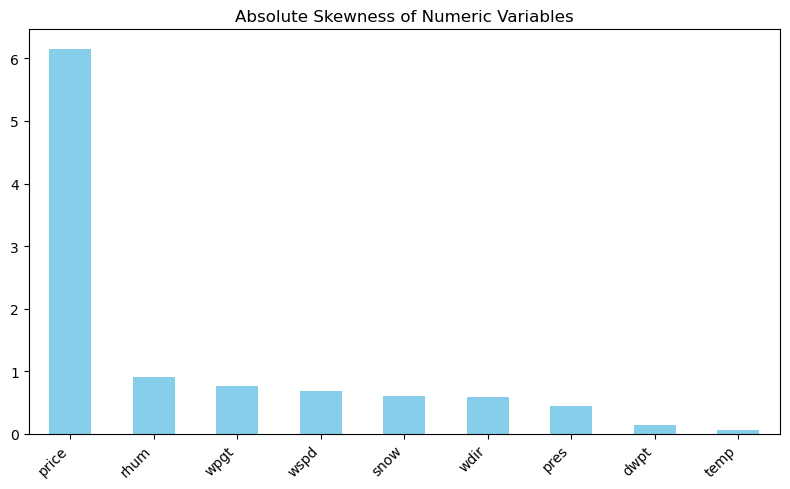

In [12]:
# Andmeveerud v.a demand
numeric_cols = ['temp','dwpt','rhum','snow','wdir','wspd','wpgt','pres','price']

# Uurime välja mis kõrvalekalded normaaljaotusest on
skew_values = df[numeric_cols].skew()

# Sort by absolute skew value (descending)
skew_values_sorted = skew_values.abs().sort_values(ascending=False)

print("Skewness of each numeric variable (unsorted):")
print(skew_values)
print("\nVariables sorted by absolute skew:")
print(skew_values_sorted)

# (Optional) Bar plot of skewness for quick overview
plt.figure(figsize=(8, 5))
skew_values_sorted.plot(kind='bar', color='skyblue')
plt.title('Absolute Skewness of Numeric Variables')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

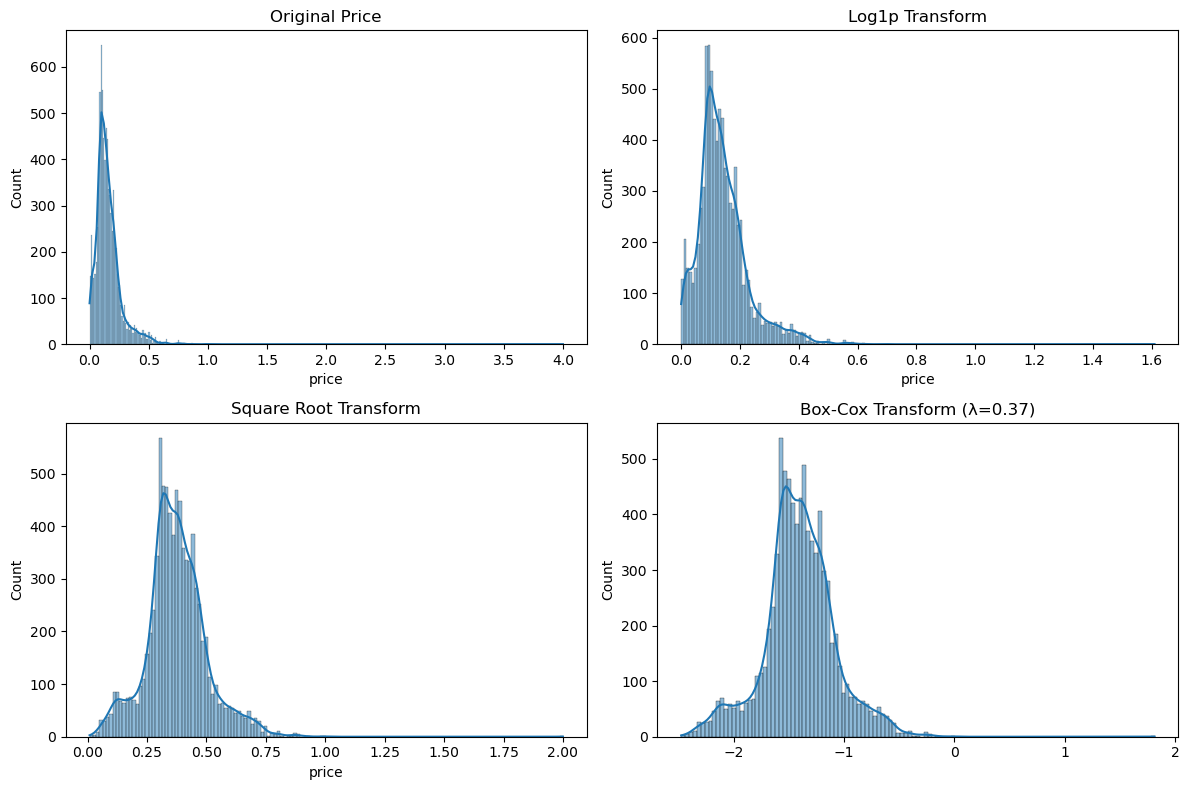

In [13]:
#Nägime et 'price' on kõvasti möädas
#kasutame erinevaid metoodikaid, et asja normaalsemaks teha
from scipy.stats import boxcox

price = df['price'].dropna()


price_log = np.log1p(price)   # log1p handles zero more gracefully
price_sqrt = np.sqrt(price)   # simple sqrt transform
price_boxcox, lmbda = boxcox(price + 0.001)  # adding a small offset


fig, axs = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(price, ax=axs[0,0], kde=True)
axs[0,0].set_title('Original Price')

sns.histplot(price_log, ax=axs[0,1], kde=True)
axs[0,1].set_title('Log1p Transform')

sns.histplot(price_sqrt, ax=axs[1,0], kde=True)
axs[1,0].set_title('Square Root Transform')

#boxpox andis kõige viisakama tulemuse
sns.histplot(price_boxcox, ax=axs[1,1], kde=True)
axs[1,1].set_title(f'Box-Cox Transform (λ={lmbda:.2f})')

plt.tight_layout()
plt.show()

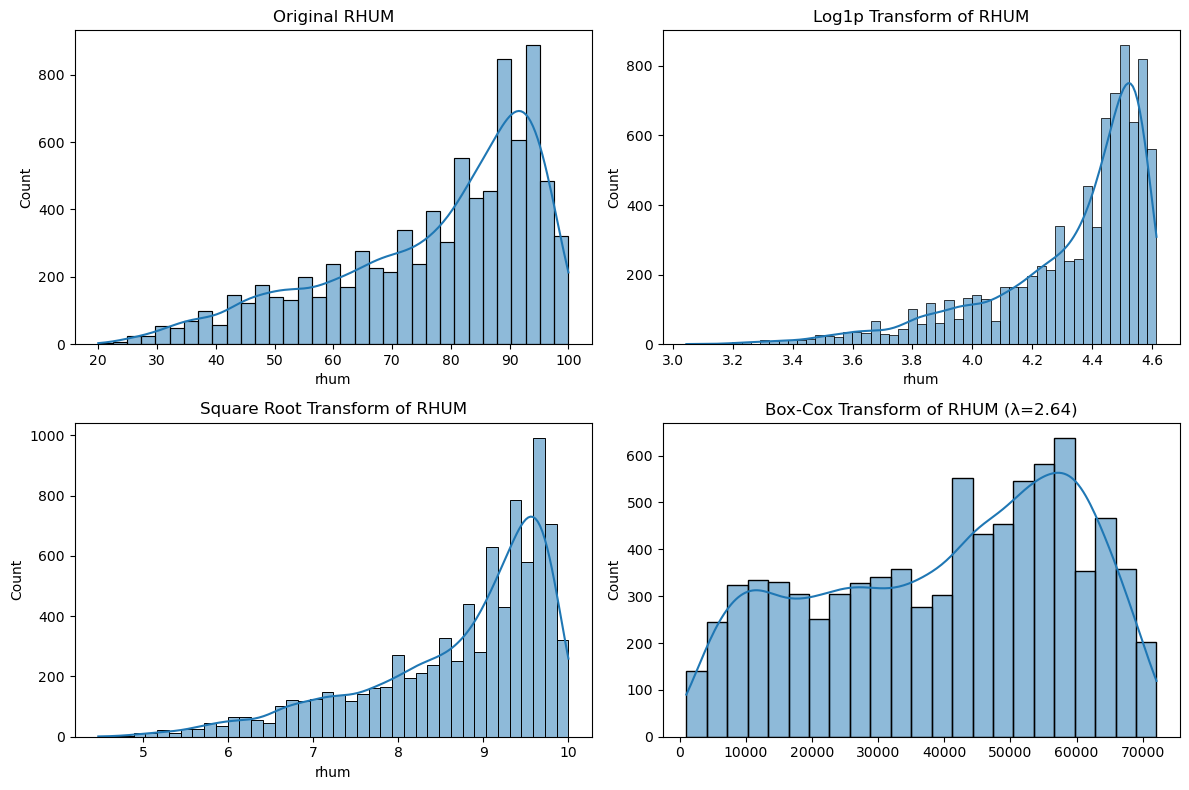

In [14]:
#proovisime sama asja suhtelise niiskusega
rhum = df['rhum'].dropna()

# Different transformations
rhum_log = np.log1p(rhum)   # handles zero
rhum_sqrt = np.sqrt(rhum)   
rhum_boxcox, lambda_rhum = boxcox(rhum + 0.001)  # small offset

# Plot them in subplots
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(rhum, ax=axs[0,0], kde=True)
axs[0,0].set_title('Original RHUM')

sns.histplot(rhum_log, ax=axs[0,1], kde=True)
axs[0,1].set_title('Log1p Transform of RHUM')

sns.histplot(rhum_sqrt, ax=axs[1,0], kde=True)
axs[1,0].set_title('Square Root Transform of RHUM')

sns.histplot(rhum_boxcox, ax=axs[1,1], kde=True)
axs[1,1].set_title(f'Box-Cox Transform of RHUM (λ={lambda_rhum:.2f})')

plt.tight_layout()
plt.show()


In [15]:
from zoneinfo import ZoneInfo  # Python 3.9+, or use 'pytz' if older

#Tekitame uued ajalised tegurid nagu nädalapäev ja "kas on nädalavahetus"

# Convert unix_timestamp (seconds) to a timezone-aware datetime in UTC
df['time_UTC'] = pd.to_datetime(df['unix_timestamp'], unit='s', utc=True)

# Now convert to Estonia local time (handles DST automatically)
df['time_local'] = df['time_UTC'].dt.tz_convert(ZoneInfo("Europe/Tallinn"))

# Create new time-based features
df['hour_local'] = df['time_local'].dt.hour
df['day_of_week_local'] = df['time_local'].dt.dayofweek
df['is_weekend'] = (df['day_of_week_local'] >= 5).astype(int)

df.head()

,time,temp,dwpt,rhum,snow,wdir,wspd,wpgt,pres,price,demand,unix_timestamp,time_UTC,time_local,hour_local,day_of_week_local,is_weekend
time_UTC,,,,,,,,,,,,,,,,,
2021-08-31 21:00:00+00:00,2021-09-01 00:00:00+03:00,11.2,10.3,94.0,NaN,320.0,7.2,16.7,1012.6,0.09016,0.577,1630443600,2021-08-31 21:00:00+00:00,2021-09-01 00:00:00+03:00,0,2,0
2021-08-31 22:00:00+00:00,2021-09-01 01:00:00+03:00,10.7,9.6,93.0,NaN,320.0,7.2,13.0,1012.6,0.09251,0.594,1630447200,2021-08-31 22:00:00+00:00,2021-09-01 01:00:00+03:00,1,2,0
2021-08-31 23:00:00+00:00,2021-09-01 02:00:00+03:00,9.9,9.0,94.0,NaN,320.0,7.2,13.0,1012.2,0.08890,0.685,1630450800,2021-08-31 23:00:00+00:00,2021-09-01 02:00:00+03:00,2,2,0
2021-09-01 00:00:00+00:00,2021-09-01 03:00:00+03:00,10.0,8.4,90.0,NaN,330.0,7.2,13.0,1011.9,0.08735,1.016,1630454400,2021-09-01 00:00:00+00:00,2021-09-01 03:00:00+03:00,3,2,0
2021-09-01 01:00:00+00:00,2021-09-01 04:00:00+03:00,9.0,8.1,94.0,NaN,300.0,3.6,13.0,1011.4,0.08688,0.677,1630458000,2021-09-01 01:00:00+00:00,2021-09-01 04:00:00+03:00,4,2,0


In [16]:
# List of numeric columns excluding demand
# Uurime välja, mis tegurid on meie jaoks kõige olulisemad
feature_cols = ['temp','dwpt','rhum','snow','wdir','wspd','wpgt','pres','price',
                'hour_local','day_of_week_local','is_weekend']

# Correlation with demand
corr_matrix = df[feature_cols + ['demand']].corr()
feature_relevance = corr_matrix['demand'].drop('demand').sort_values(key=abs, ascending=False)

print("Feature relevance (by absolute correlation):")
print(feature_relevance)


Feature relevance (by absolute correlation):
temp                -0.267757
dwpt                -0.247802
price               -0.122717
rhum                 0.095131
wpgt                 0.069006
pres                -0.065229
hour_local           0.064545
wspd                 0.049230
is_weekend           0.044453
day_of_week_local    0.032676
snow                 0.024963
wdir                -0.011811
Name: demand, dtype: float64


In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Prepare data (drop rows if you have missing values, or fill them)
feature_cols = ['temp','dwpt','rhum','snow','wdir','wspd','wpgt','pres','price',
                'hour_local','day_of_week_local','is_weekend']
X = df[feature_cols]
y = df['demand']

# Split data for training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a basic random forest
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

# Get feature importances
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

print("Feature relevance (Random Forest):")
print(importances)


Feature relevance (Random Forest):
temp                 0.184956
price                0.162423
hour_local           0.136268
pres                 0.117144
dwpt                 0.082826
wpgt                 0.081061
rhum                 0.075462
wdir                 0.069055
day_of_week_local    0.052046
wspd                 0.028054
is_weekend           0.009872
snow                 0.000833
dtype: float64


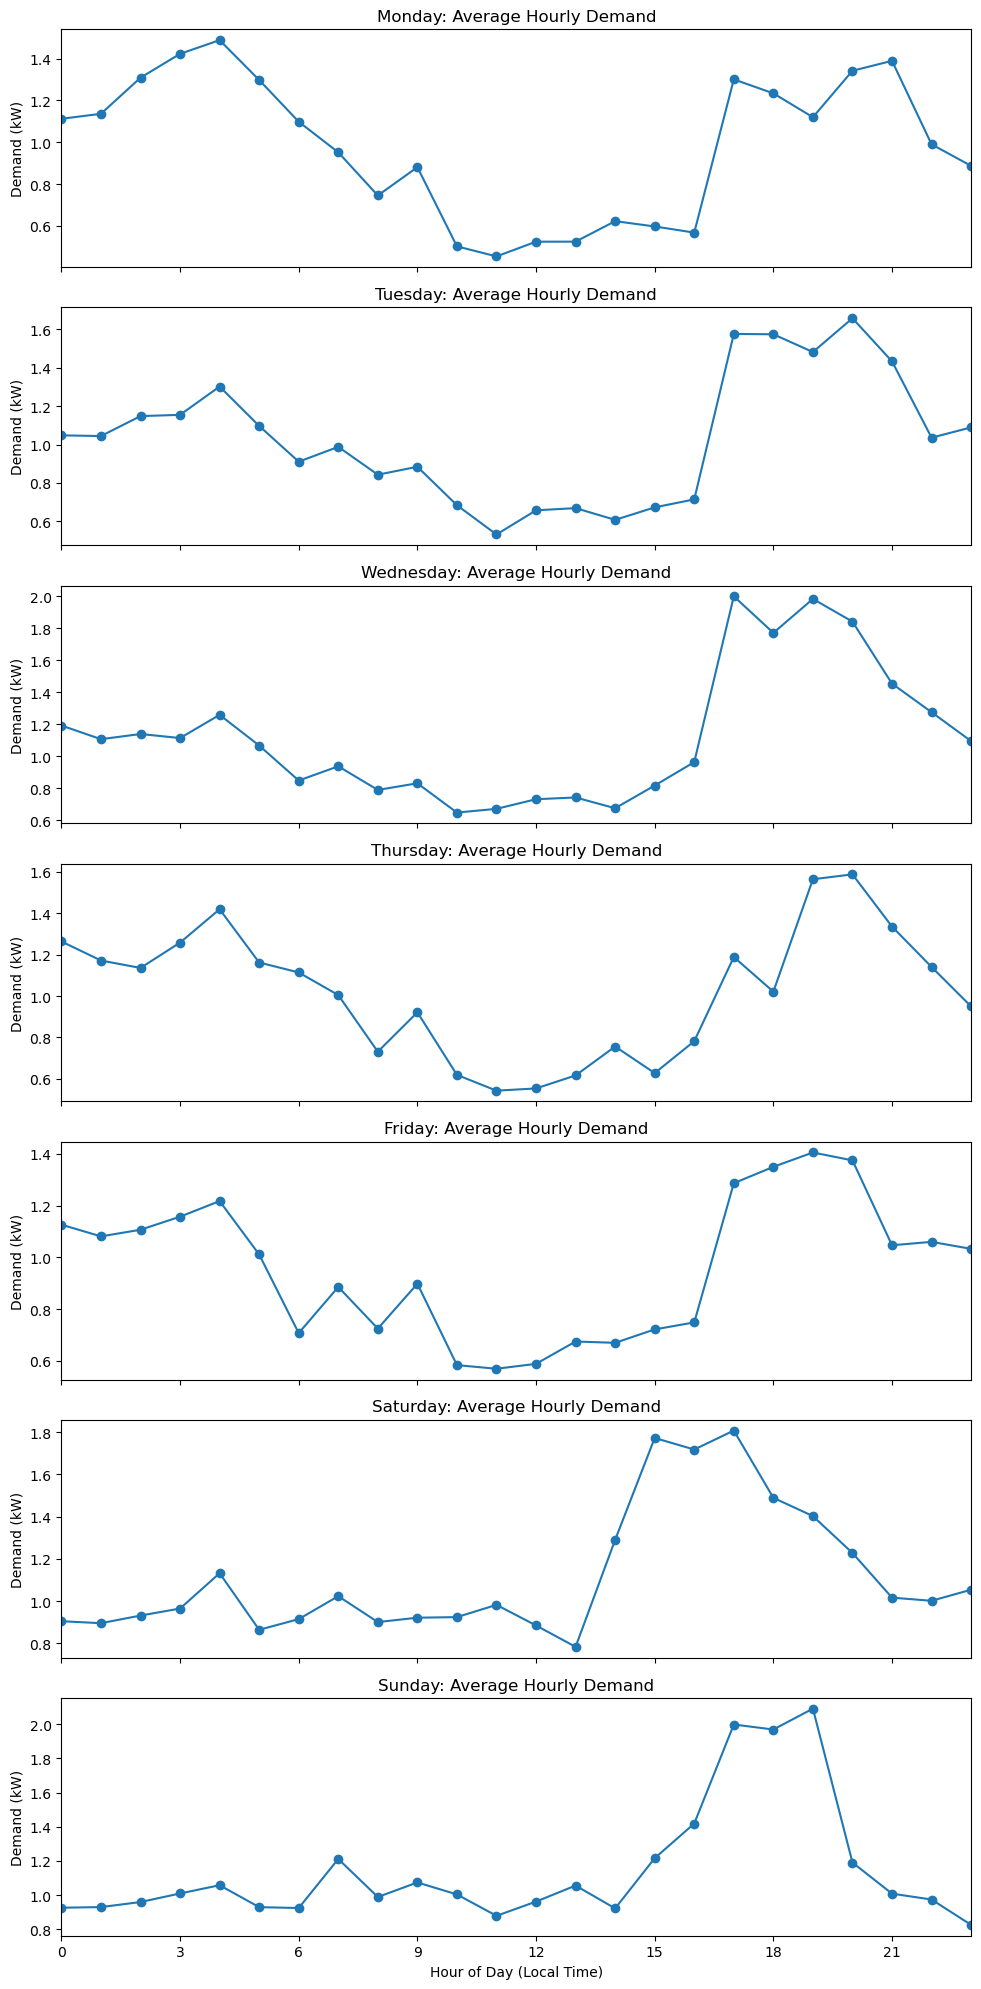

In [18]:
# Veel graafikuid, siin tarbimise ja kellaaja keskmine suhe igal nädala päeval
# Group by day_of_week_local and hour_local, then compute mean demand
avg_demand = df.groupby(['day_of_week_local', 'hour_local'])['demand'].mean().reset_index()

# Create subplots (7 rows, 1 column)
fig, axes = plt.subplots(7, 1, figsize=(10, 20), sharex=True)
days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

for i in range(7):
    day_data = avg_demand[avg_demand['day_of_week_local'] == i]
    axes[i].plot(day_data['hour_local'], day_data['demand'], marker='o')
    axes[i].set_title(f"{days[i]}: Average Hourly Demand")
    axes[i].set_ylabel("Demand (kW)")  # or (kW), depending on your data
    axes[i].set_xticks(range(0, 24, 3))  # ticks every 3 hours for clarity
    axes[i].set_xlim(0, 23)

# Label the shared X‐axis on the last subplot
axes[-1].set_xlabel("Hour of Day (Local Time)")

plt.tight_layout()
plt.show()


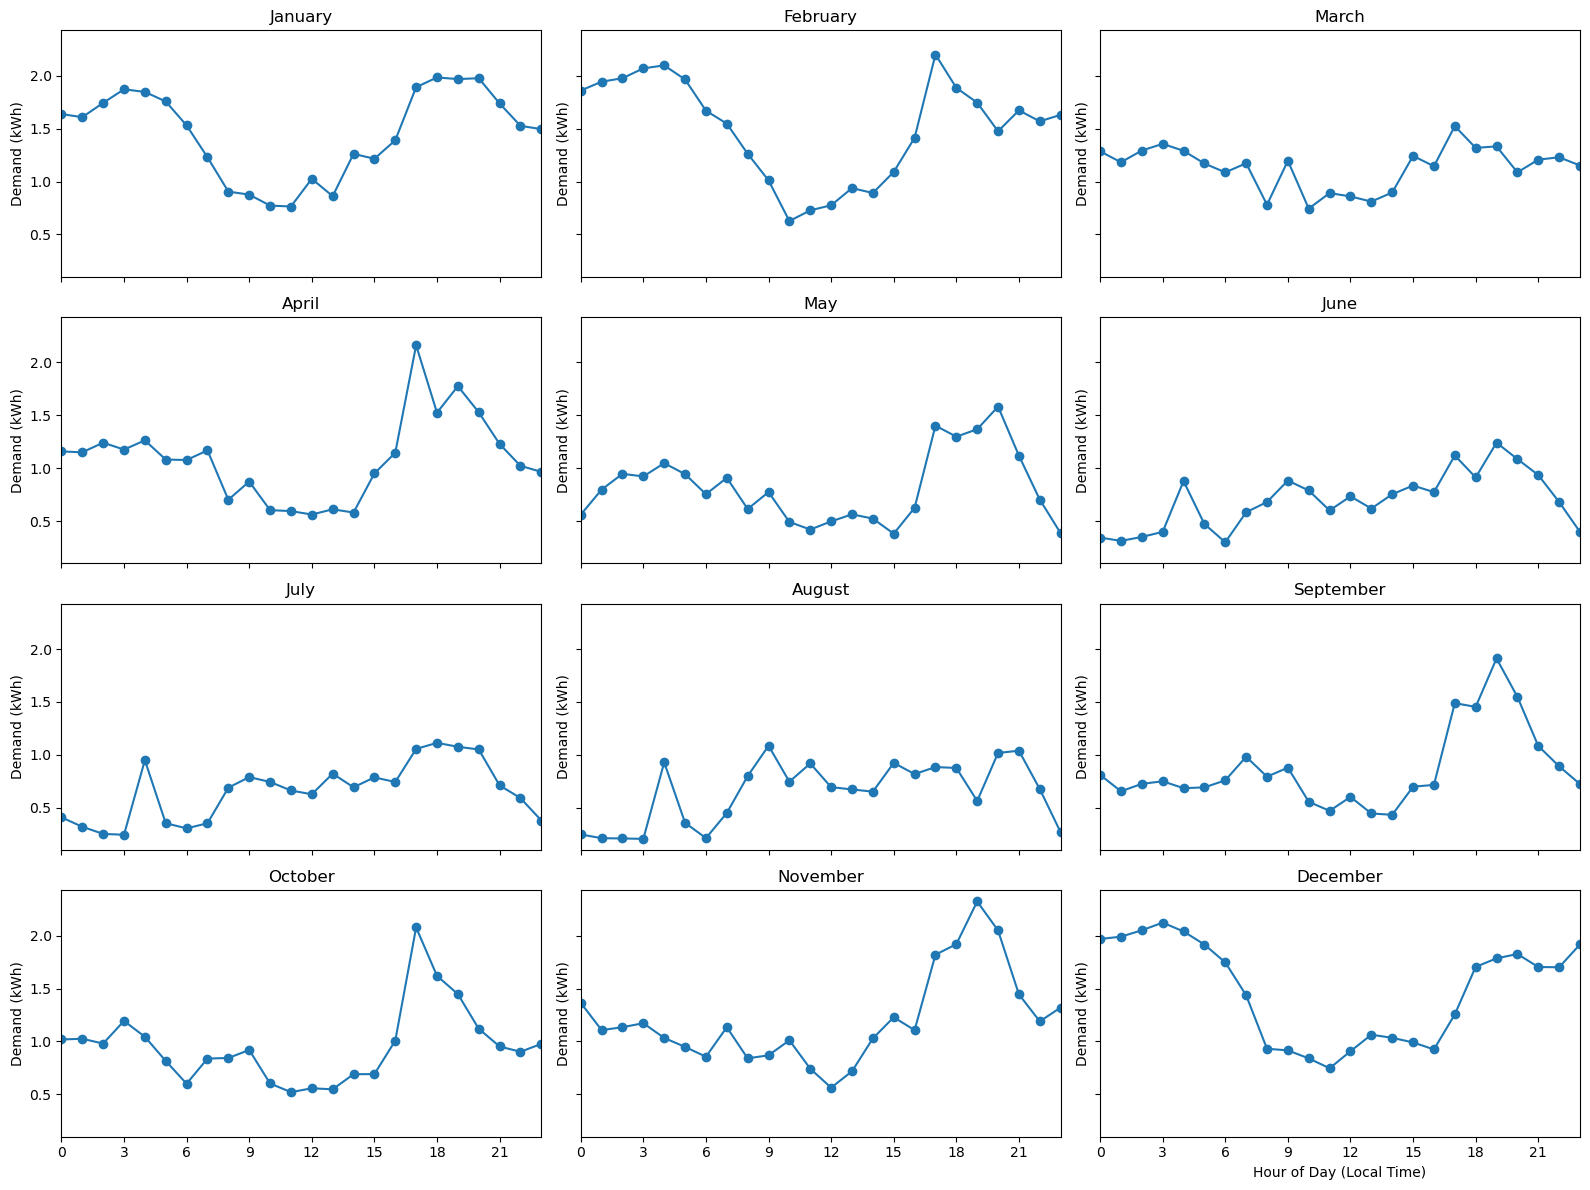

In [19]:
#Siin tarbimise ja kellaaja keskmine suhe igal kuul

import calendar

# 1. Create a 'month_local' column
df['month_local'] = df['time_local'].dt.month

# 2. Group by month_local and hour_local to get mean demand
avg_demand_month = df.groupby(['month_local', 'hour_local'])['demand'].mean().reset_index()

# 3. Create 12 subplots: let's arrange them in a 4x3 grid
fig, axes = plt.subplots(4, 3, figsize=(16, 12), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten the 2D array of axes into a 1D list

months = [calendar.month_name[m] for m in range(1, 13)]  # Month names 1-12

for i, month in enumerate(range(1, 13)):
    # Filter data for the given month
    month_data = avg_demand_month[avg_demand_month['month_local'] == month]

    # Plot hour_local (0-23) vs. average demand on the appropriate subplot
    axes[i].plot(month_data['hour_local'], month_data['demand'], marker='o')
    axes[i].set_title(months[i])
    axes[i].set_xticks(range(0, 24, 3))  # ticks at every 3 hours
    axes[i].set_xlim(0, 23)

# 4. Add common labels
for ax in axes:
    ax.set_ylabel('Demand (kWh)')  # or kW depending on your data
axes[-1].set_xlabel('Hour of Day (Local Time)')

plt.tight_layout()
plt.show()


In [20]:
#andmete paigastamine, p-value osutus väga väikseks, ehk paigastamine suurt midagi ei anna

from statsmodels.tsa.stattools import adfuller

# Ensure our data is sorted by time
df = df.sort_values('time_local')

# Quick stationarity test on demand
result = adfuller(df['demand'].dropna(), autolag='AIC')
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")

# If p-value > 0.05, data is likely non-stationary => differencing
df['demand_diff'] = df['demand'].diff()  # 1st difference

ADF Statistic: -11.350419858178665
p-value: 1.0027014025482937e-20


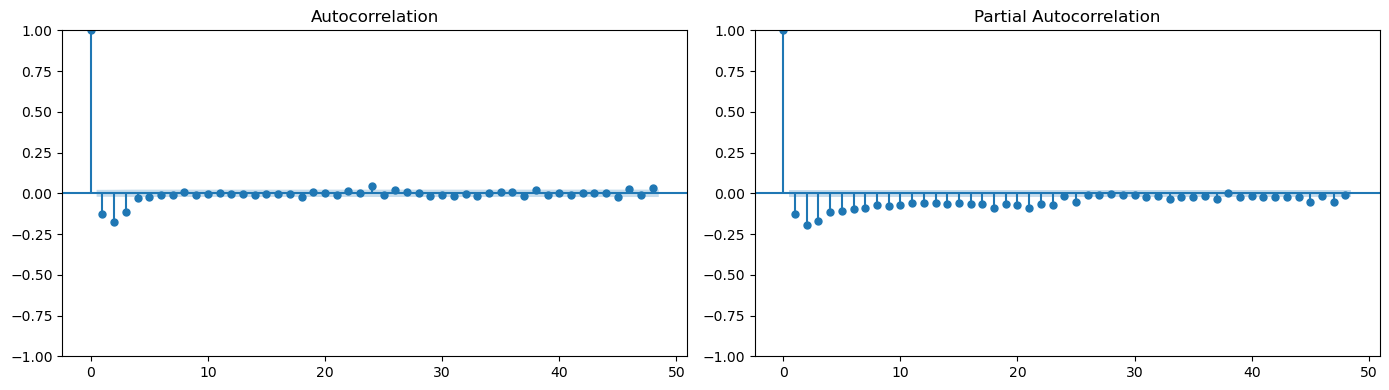

In [21]:
#Construct, analyse, and describe ACF and PACF plots

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14,4))
plot_acf(df['demand_diff'].dropna(), lags=48, ax=axes[0])
plot_pacf(df['demand_diff'].dropna(), lags=48, method='ywm', ax=axes[1])
plt.tight_layout()
plt.show()

In [22]:
#Siit Algab pikk jant erinevate ARMA-tüüpi mudelitega, otsisime parimat, kuid jäime ikkagi kõige lihtsama juurde

from statsmodels.tsa.arima.model import ARIMA

# Assume from ACF/PACF we pick (p, d, q) = (1, 1, 1) as a test
# p=1, d=1 (we differenced once), q=1
model = ARIMA(df['demand'], order=(1,0,1), enforce_stationarity=False)
model_fit = model.fit()
print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                 demand   No. Observations:                 8424
Model:                 ARIMA(1, 0, 1)   Log Likelihood              -10506.286
Date:                Tue, 17 Dec 2024   AIC                          21020.572
Time:                        07:56:04   BIC                          21048.727
Sample:                    08-31-2021   HQIC                         21030.184
                         - 08-17-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0544      0.036     29.263      0.000       0.984       1.125
ar.L1          0.5796      0.008     76.078      0.000       0.565       0.595
ma.L1          0.1068      0.009     11.393      0.0

In [23]:
from statsmodels.tsa.arima.model import ARIMA

model_diff = ARIMA(df['demand_diff'].dropna(), order=(1,0,1))  # p,q on differenced series
model_diff_fit = model_diff.fit()


In [24]:
from sklearn.metrics import mean_absolute_error

# For a quick approach, let's do an 80/20 split by index
split_idx = int(len(df)*0.8)
train_data = df['demand'][:split_idx]
test_data  = df['demand'][split_idx:]

model = ARIMA(train_data, order=(1,1,1))
model_fit = model.fit()

# Forecast the test period
predictions = model_fit.forecast(steps=len(test_data))

mae = mean_absolute_error(test_data, predictions)
print(f"MAE on test set: {mae:.3f}")


MAE on test set: 0.483


In [25]:
# Kolm tegurit paneme käiku, proovisime kõiksugu variatsioone
exog_cols = ['wdir', 'temp', 'wpgt']

df = df.sort_values('time_local')

# Create our X (exogenous) and y (target)
X = df[exog_cols]
y = df['demand']


In [26]:
# 80/20 split by index
split_idx = int(len(df)*0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]


In [27]:
from statsmodels.tsa.arima.model import ARIMA

# We can try a simple order, say (1, 0, 2) since the ADF test said data is stationary
model_exog = ARIMA(endog=y_train, exog=X_train, order=(1,0,1), enforce_stationarity=False)
model_exog_fit = model_exog.fit()
print(model_exog_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                 demand   No. Observations:                 6739
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -8680.890
Date:                Tue, 17 Dec 2024   AIC                          17375.780
Time:                        07:56:17   BIC                          17423.488
Sample:                    08-31-2021   HQIC                         17392.251
                         - 06-08-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.1422      0.075     15.221      0.000       0.995       1.289
wdir          -0.0001      0.000     -0.635      0.525      -0.001       0.000
temp          -0.0416      0.004    -10.258      0.0

In [28]:
#Kolm tegurit juures, kuid tulemus sama
from sklearn.metrics import mean_absolute_error

# Forecast the same length as the test set, providing exog=X_test
predictions_exog = model_exog_fit.forecast(steps=len(X_test), exog=X_test)

mae_exog = mean_absolute_error(y_test, predictions_exog)
print(f"MAE (ARIMAX) on test set: {mae_exog:.3f}")


MAE (ARIMAX) on test set: 0.483


In [29]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Ensure your dataframe is time-sorted
df = df.sort_values('time_local')

# Target and (optional) exogenous features
y = df['demand']
exog_cols = ['temp', 'price', 'wdir']  # If you want exogenous, put them here, e.g. ['temp','price']

X = df[exog_cols] if exog_cols else None

# Train/Test split (80/20 by index)
split_idx = int(len(df)*0.8)
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
X_train = X.iloc[:split_idx] if X is not None else None
X_test  = X.iloc[split_idx:] if X is not None else None


In [30]:
model_sarima = SARIMAX(
    endog=y_train,
    exog=X_train,                # could be None if no exog
    order=(1, 0, 1),             # ARIMA part
    seasonal_order=(1, 0, 1, 24),# Seasonal part
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_sarima_fit = model_sarima.fit()
print(model_sarima_fit.summary())


                                     SARIMAX Results                                      
Dep. Variable:                             demand   No. Observations:                 6739
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 24)   Log Likelihood               -8938.919
Date:                            Tue, 17 Dec 2024   AIC                          17893.837
Time:                                    07:57:03   BIC                          17948.332
Sample:                                08-31-2021   HQIC                         17912.655
                                     - 06-08-2022                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
temp          -0.0173      0.009     -1.988      0.047      -0.034      -0.000
price          1.2446      0.277   

In [31]:
pred_sarima = model_sarima_fit.forecast(steps=len(y_test), exog=X_test)

mae_sarima = mean_absolute_error(y_test, pred_sarima)
print(f"MAE (SARIMA) on test set: {mae_sarima:.3f}")


MAE (SARIMA) on test set: 0.498


In [32]:
from pmdarima import auto_arima

# Example usage
auto_model = auto_arima(y_train, seasonal=True, m=24,
                        start_p=0, max_p=1,
                        start_q=0, max_q=1,
                        start_P=0, max_P=1,
                        start_Q=0, max_Q=1,
                        d=0, D=0, trace=True,
                        information_criterion='aic',
                        stepwise=True)
                        
print(auto_model.summary())


Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[24] intercept   : AIC=21205.513, Time=0.12 sec
 ARIMA(1,0,0)(1,0,0)[24] intercept   : AIC=17517.019, Time=6.01 sec
 ARIMA(0,0,1)(0,0,1)[24] intercept   : AIC=18287.228, Time=4.84 sec
 ARIMA(0,0,0)(0,0,0)[24]             : AIC=25789.146, Time=0.05 sec
 ARIMA(1,0,0)(0,0,0)[24] intercept   : AIC=17544.139, Time=0.29 sec
 ARIMA(1,0,0)(1,0,1)[24] intercept   : AIC=inf, Time=23.74 sec
 ARIMA(1,0,0)(0,0,1)[24] intercept   : AIC=17519.003, Time=5.16 sec
 ARIMA(0,0,0)(1,0,0)[24] intercept   : AIC=21030.464, Time=3.78 sec
 ARIMA(1,0,1)(1,0,0)[24] intercept   : AIC=17458.656, Time=7.99 sec
 ARIMA(1,0,1)(0,0,0)[24] intercept   : AIC=17490.107, Time=0.71 sec
 ARIMA(1,0,1)(1,0,1)[24] intercept   : AIC=inf, Time=34.96 sec
 ARIMA(1,0,1)(0,0,1)[24] intercept   : AIC=17461.237, Time=6.83 sec
 ARIMA(0,0,1)(1,0,0)[24] intercept   : AIC=18275.159, Time=4.76 sec
 ARIMA(1,0,1)(1,0,0)[24]             : AIC=18157.592, Time=2.72 sec

Best model:  A

In [33]:
from sklearn.metrics import mean_absolute_error

# The model returned by auto_arima is not always fully "fit" on your entire training set.
# So explicitly re-fit it just to be safe:
best_model = auto_model.fit(y_train, exogenous=X_train)

# Forecast on the test set
n_periods = len(y_test)
pred_best = best_model.predict(n_periods=n_periods, exogenous=X_test)

# Compute MAE
mae_best = mean_absolute_error(y_test, pred_best)
print(f"MAE of the best auto_arima model: {mae_best:.3f}")


MAE of the best auto_arima model: 0.674


In [34]:
test_df = pd.read_csv('test.csv',  delimiter=',',decimal='.')
test_df.head()
test_df.info()
test_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   time    168 non-null    object 
 1   temp    168 non-null    float64
 2   dwpt    168 non-null    float64
 3   rhum    168 non-null    float64
 4   snow    0 non-null      float64
 5   wdir    168 non-null    float64
 6   wspd    168 non-null    float64
 7   wpgt    168 non-null    float64
 8   pres    168 non-null    float64
 9   price   168 non-null    float64
 10  demand  168 non-null    float64
dtypes: float64(10), object(1)
memory usage: 14.6+ KB


,temp,dwpt,rhum,snow,wdir,wspd,wpgt,pres,price,demand
count,168.000000,168.000000,168.000000,0.0,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000
mean,22.213095,15.444048,68.113095,NaN,135.255952,10.331548,17.765476,1018.311905,0.376583,0.669780
std,4.347104,1.585477,17.155654,NaN,52.996667,5.568691,6.530224,2.113311,0.224293,0.524653
min,15.100000,12.000000,33.000000,NaN,20.000000,0.000000,7.400000,1014.000000,0.000440,0.152000
25%,19.100000,14.200000,54.000000,NaN,110.000000,7.000000,14.800000,1017.000000,0.173818,0.260500
50%,21.100000,15.300000,72.000000,NaN,130.000000,9.000000,16.700000,1019.000000,0.471195,0.456500
75%,25.175000,17.000000,83.000000,NaN,150.000000,13.000000,20.400000,1020.000000,0.558843,1.007750
max,31.100000,19.400000,96.000000,NaN,350.000000,28.000000,38.900000,1021.100000,0.749440,2.600000


In [35]:
test_df['time_UTC'] = pd.to_datetime(df['time'], utc=True)
test_df['unix_timestamp'] = test_df['time_UTC'].astype('int64') // 10**9
test_df.head()


test_df['time_local'] = test_df['time_UTC'].dt.tz_convert("Europe/Tallinn")
test_df.head()

,time,temp,dwpt,rhum,snow,wdir,wspd,wpgt,pres,price,demand,time_UTC,unix_timestamp,time_local
0,2022-08-18 00:00:00+03:00,19.1,15.2,78.0,NaN,123.0,5.5,11.1,1016.0,0.50926,0.245,NaT,-9223372037,NaT
1,2022-08-18 01:00:00+03:00,18.1,15.2,83.0,NaN,97.0,5.5,13.0,1016.0,0.51134,0.178,NaT,-9223372037,NaT
2,2022-08-18 02:00:00+03:00,18.1,15.2,83.0,NaN,95.0,3.7,11.1,1016.0,0.47990,0.203,NaT,-9223372037,NaT
3,2022-08-18 03:00:00+03:00,16.7,15.7,94.0,NaN,350.0,0.0,11.1,1016.5,0.42430,0.215,NaT,-9223372037,NaT
4,2022-08-18 04:00:00+03:00,17.1,15.1,88.0,NaN,90.0,2.0,9.3,1016.0,0.32401,1.043,NaT,-9223372037,NaT


In [36]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# Load TRAIN
train_df = pd.read_csv("train.csv")
train_df['time_UTC'] = pd.to_datetime(train_df['time'], utc=True)
train_df['time_local'] = train_df['time_UTC'].dt.tz_convert("Europe/Tallinn")
train_df = train_df.sort_values('time_local').reset_index(drop=True)

# Load TEST
test_df = pd.read_csv("test.csv")
test_df['time_UTC'] = pd.to_datetime(test_df['time'], utc=True)
test_df['time_local'] = test_df['time_UTC'].dt.tz_convert("Europe/Tallinn")
test_df = test_df.sort_values('time_local').reset_index(drop=True)

# Confirm test range: ~168 rows, from 2022-08-18 00:00+03:00 to 2022-08-24 23:00+03:00
print(test_df[['time_local','demand']].head(), test_df[['time_local','demand']].tail())


                 time_local  demand
0 2022-08-18 00:00:00+03:00   0.245
1 2022-08-18 01:00:00+03:00   0.178
2 2022-08-18 02:00:00+03:00   0.203
3 2022-08-18 03:00:00+03:00   0.215
4 2022-08-18 04:00:00+03:00   1.043                    time_local  demand
163 2022-08-24 19:00:00+03:00   0.678
164 2022-08-24 20:00:00+03:00   0.457
165 2022-08-24 21:00:00+03:00   0.500
166 2022-08-24 22:00:00+03:00   2.321
167 2022-08-24 23:00:00+03:00   0.678


In [37]:
test_start = test_df['time_local'].min()  # 2022-08-18 00:00:00+03:00
test_end   = test_df['time_local'].max()  # 2022-08-24 23:00:00+03:00

# Generate a list of daily start times in the test range
# 7 days => 2022-08-18 ... 2022-08-24
daily_starts = pd.date_range(start=test_start.floor('D'),
                             end=test_end.floor('D'),
                             freq='D',
                             tz="Europe/Tallinn")

all_predictions = []  # to store each day's forecast
HORIZON = 24          # forecast 24h at a time

# Make a copy so we can append actuals day by day
rolling_train = train_df.copy()

for day_start in daily_starts:
    # day_end is day_start + 24h minus 1 hour
    day_end = day_start + pd.Timedelta(hours=23)
    
    # 1) Fit model on rolling_train (everything up to day_start)
    mask = rolling_train['time_local'] < day_start
    train_data = rolling_train.loc[mask, 'demand']

    # Basic ARIMA(1,0,1) – feel free to adjust
    model = ARIMA(train_data, order=(1,0,1), enforce_stationarity=False)
    model_fit = model.fit()
    
    # 2) Forecast 24 hours
    forecast_24h = model_fit.forecast(steps=HORIZON)
    
    # 3) Align forecast timestamps
    # The 24h forecast covers day_start...day_end
    future_times = pd.date_range(start=day_start, periods=HORIZON, freq='H', tz="Europe/Tallinn")
    temp_df = pd.DataFrame({'time_local': future_times, 'demand_pred': forecast_24h.values})
    
    # Merge the *actual* test data for these 24 hours
    actuals_df = test_df[(test_df['time_local'] >= day_start) & (test_df['time_local'] <= day_end)].copy()
    day_merged = pd.merge(actuals_df[['time_local','demand']], temp_df, on='time_local', how='left')
    
    # 4) Store the results
    all_predictions.append(day_merged)
    
    # 5) "Roll" the training data forward by adding the newly revealed actual day to rolling_train
    # so next day's forecast sees today's actual data.
    rolling_train = pd.concat([rolling_train, actuals_df], ignore_index=True)

# Concatenate all daily forecasts
final_preds = pd.concat(all_predictions, ignore_index=True).sort_values('time_local')

# Evaluate overall performance
mae_rolling = mean_absolute_error(final_preds['demand'], final_preds['demand_pred'])
print(f"Rolling 24h Forecast MAE: {mae_rolling:.3f}")


Rolling 24h Forecast MAE: 0.539


In [38]:
# Naïve forecast for 24h = last known demand
last_obs = train_data.iloc[-1]
forecast_24h = np.full(HORIZON, last_obs)


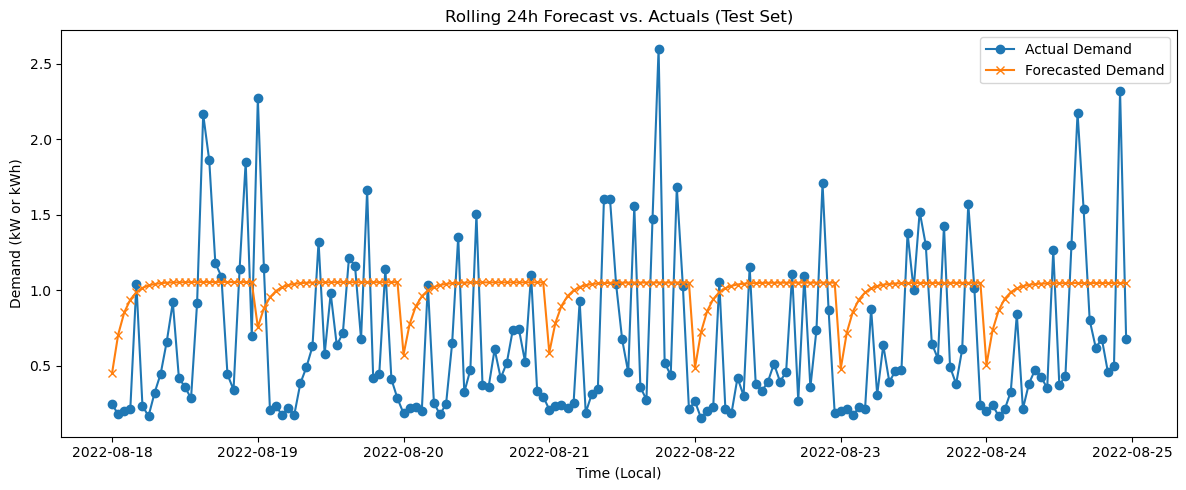

In [39]:
import matplotlib.pyplot as plt

# 'final_preds' should already have columns: ['time_local', 'demand', 'demand_pred']

# 1. Plot Actual vs Forecast over the 7-day test range
plt.figure(figsize=(12,5))
plt.plot(final_preds['time_local'], final_preds['demand'], label='Actual Demand', marker='o')
plt.plot(final_preds['time_local'], final_preds['demand_pred'], label='Forecasted Demand', marker='x')
plt.title('Rolling 24h Forecast vs. Actuals (Test Set)')
plt.xlabel('Time (Local)')
plt.ylabel('Demand (kW or kWh)')
plt.legend()
plt.tight_layout()
plt.show()


In [42]:
test_df = pd.read_csv("test.csv")
test_df['time_UTC'] = pd.to_datetime(test_df['time'], utc=True)
# Convert to local time, just like the training data
test_df['time_local'] = test_df['time_UTC'].dt.tz_convert("Europe/Tallinn")

# Append test_df to training df so we have a continuous timeline
full_df = pd.concat([df, test_df], ignore_index=True, axis=0)

# Sort by time
full_df = full_df.sort_values('time_local').reset_index(drop=True)


In [44]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# --- Load Training Data ---
df_train = pd.read_csv("train.csv")
df_train['time_UTC'] = pd.to_datetime(df_train['time'], utc=True)
df_train['time_local'] = df_train['time_UTC'].dt.tz_convert("Europe/Tallinn")
df_train.sort_values('time_local', inplace=True)
df_train.reset_index(drop=True, inplace=True)

# --- Load Test Data ---
df_test = pd.read_csv("test.csv")
df_test['time_UTC'] = pd.to_datetime(df_test['time'], utc=True)
df_test['time_local'] = df_test['time_UTC'].dt.tz_convert("Europe/Tallinn")
df_test.sort_values('time_local', inplace=True)
df_test.reset_index(drop=True, inplace=True)

print("Train Range:", df_train['time_local'].min(), "to", df_train['time_local'].max())
print("Test Range:", df_test['time_local'].min(), "to", df_test['time_local'].max())


Train Range: 2021-09-01 00:00:00+03:00 to 2022-08-17 23:00:00+03:00
Test Range: 2022-08-18 00:00:00+03:00 to 2022-08-24 23:00:00+03:00


In [46]:
# Start/end times in test
test_start = df_test['time_local'].min()  # 2022-08-18 00:00
test_end   = df_test['time_local'].max()  # 2022-08-24 23:00

# Generate daily start timestamps for the 7 days in the test set
daily_starts = pd.date_range(
    start=test_start.floor('D'),
    end=test_end.floor('D'),
    freq='D',
    tz="Europe/Tallinn"
)

rolling_train = df_train.copy()  # a copy we can append to
all_predictions = []
HORIZON = 24  # forecasting 24h each iteration

for day_start in daily_starts:
    day_end = day_start + pd.Timedelta(hours=23)
    
    # 1) TRAIN the model with data up to "day_start" (exclusive)
    mask_train = rolling_train['time_local'] < day_start
    train_data = rolling_train.loc[mask_train, 'demand']
    
    # Fit a simple ARIMA(1,0,1)
    model = ARIMA(train_data, order=(1,0,1), enforce_stationarity=False)
    model_fit = model.fit()
    
    # 2) FORECAST the next 24 hours
    # We'll create a date range for these 24 hours
    future_times = pd.date_range(start=day_start, periods=HORIZON, freq='H', tz="Europe/Tallinn")
    forecast_24h = model_fit.forecast(steps=HORIZON)
    
    # Build a small DataFrame of predictions
    pred_df = pd.DataFrame({
        'time_local': future_times,
        'demand_pred': forecast_24h.values
    })
    
    # 3) MERGE with actual test data for these 24 hours
    actual_df = df_test[(df_test['time_local'] >= day_start) & (df_test['time_local'] <= day_end)][['time_local','demand']]
    merged_df = pd.merge(actual_df, pred_df, on='time_local', how='left')
    all_predictions.append(merged_df)
    
    # 4) UPDATE rolling_train with the actual data from day_start to day_end
    # so next iteration can see the newly revealed data
    rolling_train = pd.concat([rolling_train, actual_df], ignore_index=True)
    
# Concatenate day-by-day results
final_predictions = pd.concat(all_predictions, ignore_index=True).sort_values('time_local')

# Evaluate with MAE
mae_rolling = mean_absolute_error(final_predictions['demand'], final_predictions['demand_pred'])
print(f"Rolling 24h Forecast MAE (Baseline ARIMA): {mae_rolling:.3f}")


Rolling 24h Forecast MAE (Baseline ARIMA): 0.539


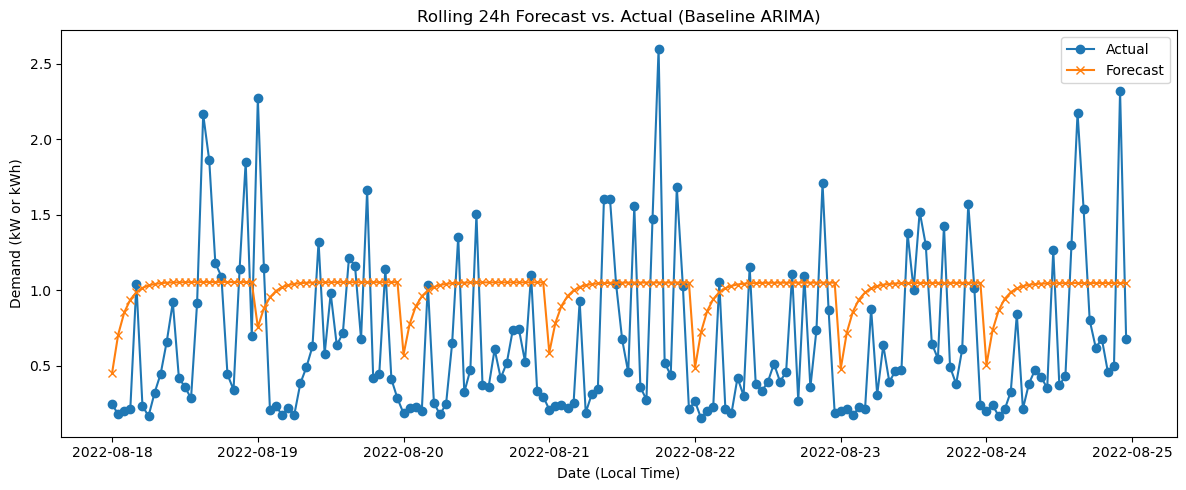

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(final_predictions['time_local'], final_predictions['demand'], label='Actual', marker='o')
plt.plot(final_predictions['time_local'], final_predictions['demand_pred'], label='Forecast', marker='x')
plt.title('Rolling 24h Forecast vs. Actual (Baseline ARIMA)')
plt.xlabel('Date (Local Time)')
plt.ylabel('Demand (kW or kWh)')
plt.legend()
plt.tight_layout()
plt.show()


In [51]:
df_train['hour_local'] = df_train['time_local'].dt.hour
df_test['hour_local'] = df_test['time_local'].dt.hour


In [56]:
print(train_X.isna().sum())  # Check missing values in train_X
print(test_X_24h.isna().sum())  # Check missing values in test_X_24h
print(np.isinf(train_X).sum())  # Check infinite values in train_X
print(np.isinf(test_X_24h).sum())  # Check infinite values in test_X_24h
train_X = train_X.dropna()
train_y = train_y.loc[train_X.index]  # Ensure `train_y` matches updated `train_X`


temp          24
price         24
hour_local    24
dtype: int64
temp          0
price         0
hour_local    0
dtype: int64
temp          0
price         0
hour_local    0
dtype: int64
temp          0
price         0
hour_local    0
dtype: int64


In [57]:
train_X = train_X.dropna()
train_y = train_y.loc[train_X.index]  # Ensure `train_y` matches updated `train_X`
train_X = train_X.fillna(method='ffill').fillna(method='bfill')
train_X['temp'].fillna(train_X['temp'].mean(), inplace=True)
train_X['price'].fillna(train_X['price'].mean(), inplace=True)
train_X['hour_local'].fillna(train_X['hour_local'].mode()[0], inplace=True)


In [59]:
rolling_train = df_train.copy()
all_naive_preds = []

for day_start in daily_starts:
    day_end = day_start + pd.Timedelta(hours=23)
    
    # Last known demand before day_start
    mask_train = rolling_train['time_local'] < day_start
    last_obs = rolling_train.loc[mask_train, 'demand'].iloc[-1]

    # Forecast next 24h with the same last value
    future_times = pd.date_range(start=day_start, periods=24, freq='H', tz="Europe/Tallinn")
    naive_24h = [last_obs] * 24
    
    pred_naive_df = pd.DataFrame({
        'time_local': future_times,
        'demand_pred': naive_24h
    })
    actual_df = df_test[(df_test['time_local'] >= day_start) & (df_test['time_local'] <= day_end)][['time_local','demand']]
    merged_naive = pd.merge(actual_df, pred_naive_df, on='time_local', how='left')
    all_naive_preds.append(merged_naive)
    
    # Update rolling_train
    rolling_train = pd.concat([rolling_train, actual_df], ignore_index=True)

final_naive_preds = pd.concat(all_naive_preds, ignore_index=True).sort_values('time_local')
mae_naive = mean_absolute_error(final_naive_preds['demand'], final_naive_preds['demand_pred'])
print(f"Rolling 24h Forecast MAE (Naïve): {mae_naive:.3f}")


Rolling 24h Forecast MAE (Naïve): 0.435
